In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Çalışma Ortamı: {device}")
if device.type == 'cuda':
    print(f"   Ekran Kartı: {torch.cuda.get_device_name(0)}")

DATA_DIR = r'C:\Users\user\Desktop\DerinProjem\garbage-dataset'

✅ Çalışma Ortamı: cuda
   Ekran Kartı: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Eğitim verisi için: Rastgele değiştirmeler yapıyoruz 
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Resmin %80'ine odaklan
    transforms.RandomHorizontalFlip(),      # Yatay çevir
    transforms.RandomRotation(15),          # Hafif döndür
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Işıkla oyna
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Test verisi için: Sadece boyutluyoruz (Orijinal kalsın)
test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
classes = full_dataset.classes
print(f"📂 Sınıflar ({len(classes)} adet): {classes}")

📂 Sınıflar (10 adet): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [3]:
class_counts = {c: 0 for c in classes}
for _, label in full_dataset.samples:
    class_counts[classes[label]] += 1

print("\n📊 Veri Dağılımı (Hangi sınıftan kaç tane var?):")
print(class_counts)

# Ağırlık hesabı: Az örneği olana daha fazla ağırlık 
total_samples = sum(class_counts.values())
weights = [total_samples / class_counts[c] for c in classes]

# Bu ağırlıkları Loss fonksiyonuna vereceğiz
class_weights = torch.FloatTensor(weights).to(device)
print(f"\n⚖️ Hesaplanan Ağırlıklar: {[round(w, 2) for w in weights]}")


📊 Veri Dağılımı (Hangi sınıftan kaç tane var?):
{'battery': 944, 'biological': 997, 'cardboard': 1825, 'clothes': 5327, 'glass': 3061, 'metal': 1020, 'paper': 1680, 'plastic': 1984, 'shoes': 1977, 'trash': 947}

⚖️ Hesaplanan Ağırlıklar: [20.93, 19.82, 10.83, 3.71, 6.46, 19.37, 11.76, 9.96, 10.0, 20.87]


In [4]:
# Stratified Split 
targets = [s[1] for s in full_dataset.samples]

# %70 Eğitim, %30 Diğer
train_idx, temp_idx = train_test_split(
    np.arange(len(full_dataset)), test_size=0.3, stratify=targets, random_state=42
)

# Kalan %30'u -> %15 Validation, %15 Test 
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42
)

# Subsetleri oluşturuyoruz
train_ds = Subset(full_dataset, train_idx)
# Val ve Test için 'temiz' transform kullanıyoruz (Augmentation yok)
val_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tfms), val_idx)
test_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tfms), test_idx)

# DataLoader
BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ Veri Hazır! Eğitim: {len(train_ds)}, Doğrulama: {len(val_ds)}, Test: {len(test_ds)}")


✅ Veri Hazır! Eğitim: 13833, Doğrulama: 2964, Test: 2965


In [5]:
def get_alexnet_model(num_classes):
    print("\n🛠️ AlexNet Modeli İndiriliyor...")
    model = models.alexnet(pretrained=True)
    
    # Feature Extraction (Özellik Çıkarımı) katmanlarını dondur
    # Çünkü bu katmanlar zaten milyonlarca resimle eğitildi, işi biliyorlar.
    for param in model.features.parameters():
        param.requires_grad = False
    
    # Classifier (Sınıflandırıcı) Kısmı:
    # AlexNet'in son katmanı (indeks 6) bir Linear katmandır.
    # Bunu kendi sınıfımıza göre değiştiriyoruz.
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)
    
    return model.to(device)

model = get_alexnet_model(len(classes))

# Loss ve Optimizer
# Hesapladığımız ağırlıkları (class_weights) buraya veriyoruz!
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Sadece son kısmı (classifier) eğiteceğiz, öğrenme hızını düşük tutuyoruz.
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)


🛠️ AlexNet Modeli İndiriliyor...


C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
def train_model(model, train_loader, val_loader, epochs=15):
    start_time = time.time()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    print(f"\n🚀 Eğitim Başlıyor... ({epochs} Epoch sürecek)")
    print("-" * 60)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # --- SHAPE DEBUGGING ---
        if epoch == 0:
            # İlk batch'i manuel çekip kontrol edelim
            inputs_sample, labels_sample = next(iter(train_loader))
            print(f"🔍 [DEBUG] Input Shape: {inputs_sample.shape} (32 resim, 3 kanal RGB, 224x224)")
            print(f"🔍 [DEBUG] Label Shape: {labels_sample.shape} (32 etiket)")
            print("-" * 30)

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()         # Önceki türevleri temizle
            outputs = model(inputs)       # Tahmin yap
            loss = criterion(outputs, labels) # Hatayı hesapla
            loss.backward()               # Geriye yayılım (Backprop)
            optimizer.step()              # Ağırlıkları güncelle
            
            running_loss += loss.item() * inputs.size(0)

        # Validation (Doğrulama) Kısmı
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

        # En iyi modeli hafızada tut
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'\n✨ Eğitim Tamamlandı! Süre: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'🏆 En İyi Val Accuracy: {best_acc:.4f}')
    
    # En iyi ağırlıkları modele yükle
    model.load_state_dict(best_wts)
    return model, history

In [7]:
# Eğitimi başlatıyoruz
trained_alexnet, history = train_model(model, train_dl, val_dl, epochs=15)


🚀 Eğitim Başlıyor... (15 Epoch sürecek)
------------------------------------------------------------
🔍 [DEBUG] Input Shape: torch.Size([32, 3, 224, 224]) (32 resim, 3 kanal RGB, 224x224)
🔍 [DEBUG] Label Shape: torch.Size([32]) (32 etiket)
------------------------------
Epoch 1/15 | Train Loss: 0.7426 | Val Loss: 0.4295 | Val Acc: 0.8677
Epoch 2/15 | Train Loss: 0.4515 | Val Loss: 0.4238 | Val Acc: 0.8907
Epoch 3/15 | Train Loss: 0.3618 | Val Loss: 0.3597 | Val Acc: 0.8968
Epoch 4/15 | Train Loss: 0.2992 | Val Loss: 0.3218 | Val Acc: 0.9086
Epoch 5/15 | Train Loss: 0.2586 | Val Loss: 0.3339 | Val Acc: 0.9096
Epoch 6/15 | Train Loss: 0.2299 | Val Loss: 0.3013 | Val Acc: 0.9214
Epoch 7/15 | Train Loss: 0.2183 | Val Loss: 0.3104 | Val Acc: 0.9177
Epoch 8/15 | Train Loss: 0.1895 | Val Loss: 0.2872 | Val Acc: 0.9271
Epoch 9/15 | Train Loss: 0.1712 | Val Loss: 0.3071 | Val Acc: 0.9248
Epoch 10/15 | Train Loss: 0.1531 | Val Loss: 0.3336 | Val Acc: 0.9177
Epoch 11/15 | Train Loss: 0.1653 | Val


📈 Grafikler çiziliyor...


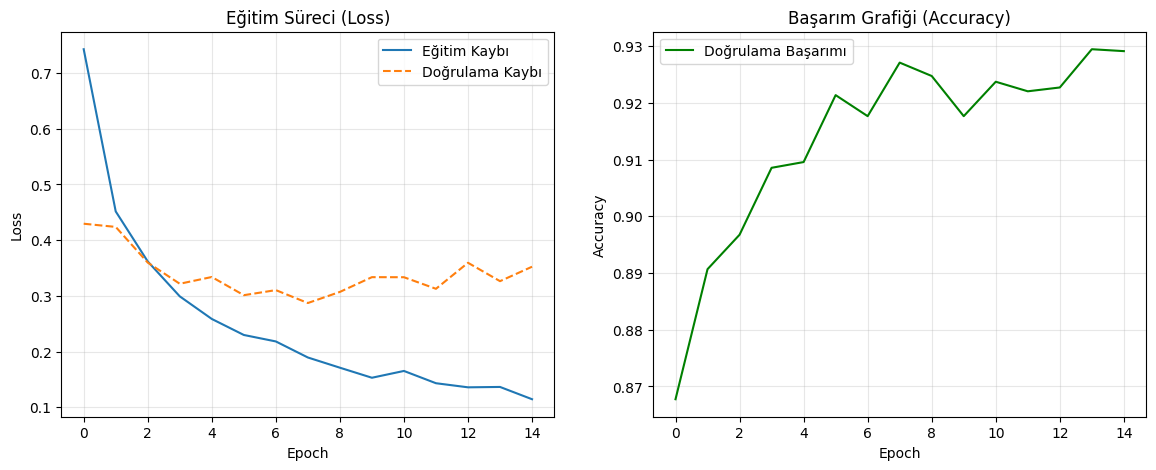

In [8]:
def plot_history(history):
    epochs_range = range(len(history['train_loss']))
    
    plt.figure(figsize=(14, 5))
    
    # 1. Grafik: Kayıp (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Eğitim Kaybı')
    plt.plot(epochs_range, history['val_loss'], label='Doğrulama Kaybı', linestyle='--')
    plt.title('Eğitim Süreci (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Grafik: Başarım (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_acc'], label='Doğrulama Başarımı', color='green')
    plt.title('Başarım Grafiği (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

print("\n📈 Grafikler çiziliyor...")
plot_history(history)

In [9]:
def evaluate_detailed(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("\n🧪 Test Seti üzerinde analiz yapılıyor...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

  
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    
    results = []
    for cls in class_names:
        d = report_dict[cls]
        results.append({
            "Sınıf": cls,
            "Accuracy": d['recall'], 
            "Precision": d['precision'],
            "Recall": d['recall'],
            "F1-Score": d['f1-score']
        })
    
    df = pd.DataFrame(results)
   
    df = df[["Sınıf", "Accuracy", "Precision", "Recall", "F1-Score"]]
    
    print("\n" + "="*50)
    print("📊 ALEXNET - DETAYLI PERFORMANS TABLOSU")
    print("="*50)
    print(df.round(4).to_string(index=False))
    
   
    df.to_csv('alexnet_detailed_results.csv', index=False)
    print("\n💾 Sonuçlar 'alexnet_detailed_results.csv' dosyasına kaydedildi.")
    
    return all_labels, all_preds

y_true, y_pred = evaluate_detailed(trained_alexnet, test_dl, classes)


🧪 Test Seti üzerinde analiz yapılıyor...

📊 ALEXNET - DETAYLI PERFORMANS TABLOSU
     Sınıf  Accuracy  Precision  Recall  F1-Score
   battery    0.9504     0.9178  0.9504    0.9338
biological    0.9530     0.9342  0.9530    0.9435
 cardboard    0.9161     0.9228  0.9161    0.9194
   clothes    0.9712     0.9810  0.9712    0.9761
     glass    0.8913     0.9213  0.8913    0.9061
     metal    0.9020     0.7624  0.9020    0.8263
     paper    0.8651     0.8617  0.8651    0.8634
   plastic    0.8591     0.8767  0.8591    0.8678
     shoes    0.8855     0.9359  0.8855    0.9100
     trash    0.8592     0.8026  0.8592    0.8299

💾 Sonuçlar 'alexnet_detailed_results.csv' dosyasına kaydedildi.



📷 Örnek Tahminler Gösteriliyor...


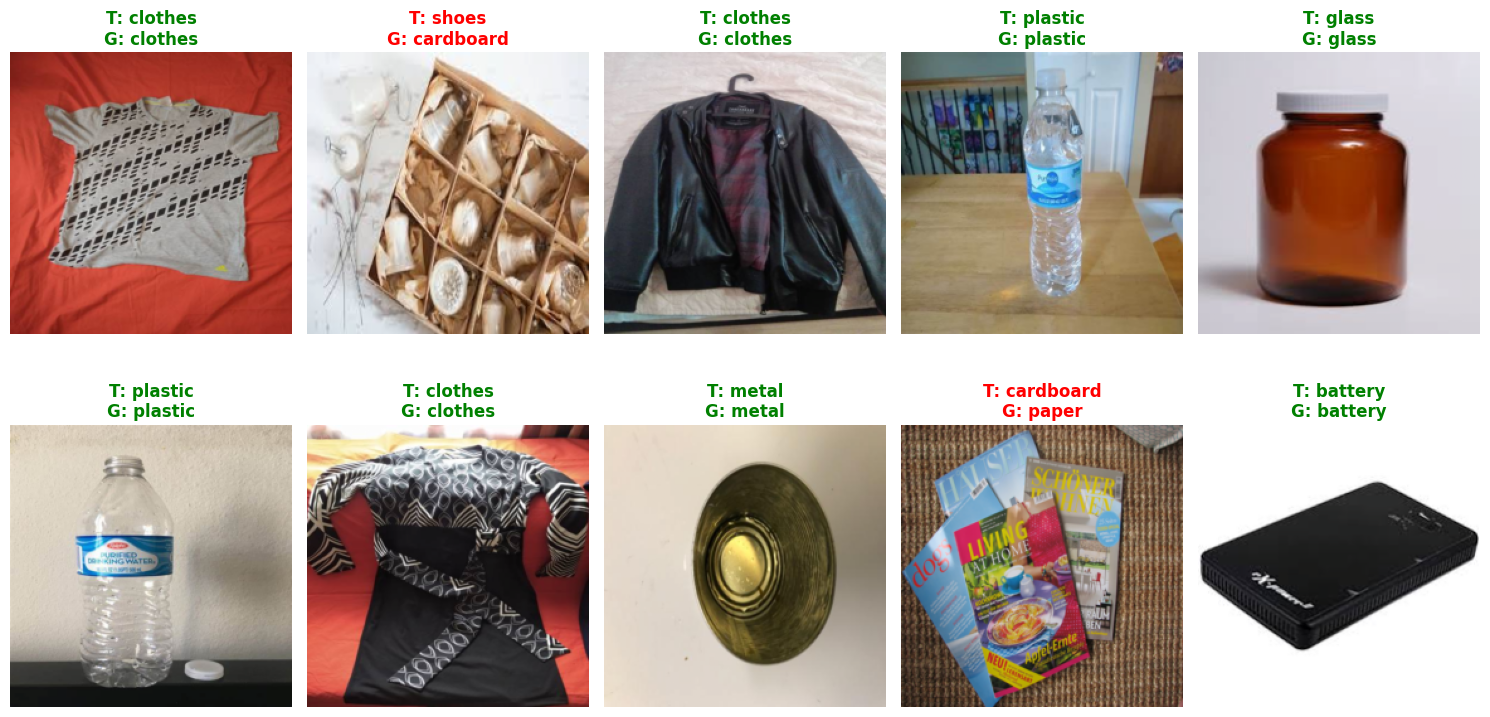

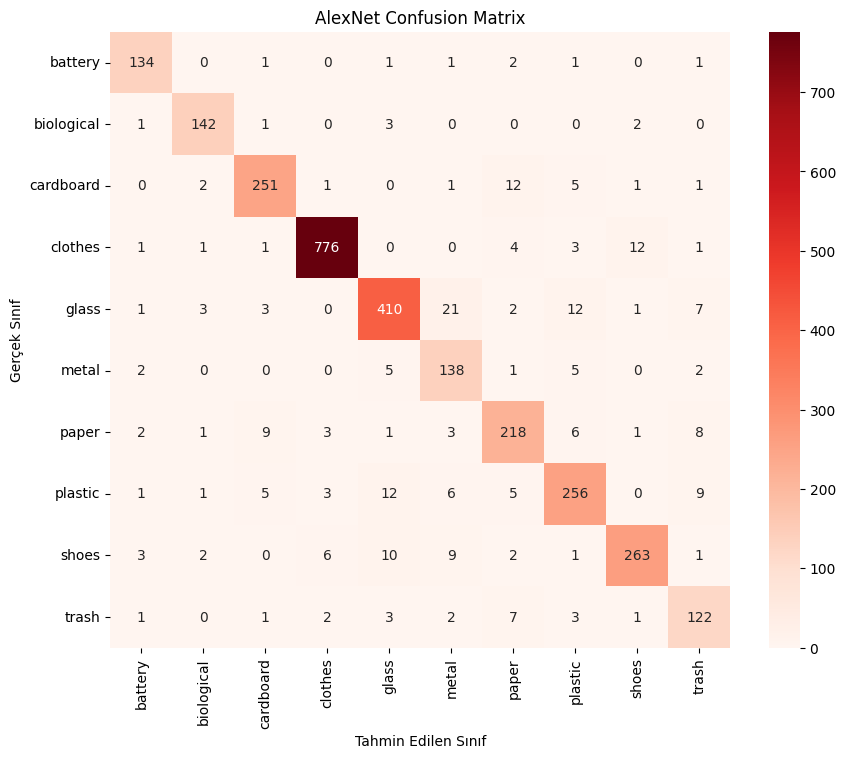

In [10]:
def visualize_predictions(model, loader, class_names, num_images=10):
    model.eval()
    images_shown = 0
    
    # Resmi eski haline (normal görüntüye) çevirmek için
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    plt.figure(figsize=(15, 8))
    print("\n📷 Örnek Tahminler Gösteriliyor...")

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                
                ax = plt.subplot(2, 5, images_shown + 1)
                ax.axis('off')
                
               
                img = inputs.cpu().data[j]
                img = inv_normalize(img)
                img = np.transpose(img.numpy(), (1, 2, 0))
                img = np.clip(img, 0, 1)
                plt.imshow(img)
                
                
                pred_label = class_names[preds[j]]
                true_label = class_names[labels[j]]
                color = 'green' if pred_label == true_label else 'red'
                
                ax.set_title(f"T: {pred_label}\nG: {true_label}", color=color, fontweight='bold')
                images_shown += 1
            
            if images_shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

visualize_predictions(trained_alexnet, test_dl, classes)

# ---(Confusion Matrix) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title('AlexNet Confusion Matrix')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

In [12]:
def evaluate_fixed(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("\n🧪 Test Seti Analiz Ediliyor...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

  
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
   
    acc = report_dict['accuracy']
    macro_f1 = report_dict['macro avg']['f1-score']
    weighted_f1 = report_dict['weighted avg']['f1-score']
    
    print("\n" + "="*40)
    print("🌍 MODEL GENEL PERFORMANSI")
    print("="*40)
    print(f"Genel Doğruluk (Accuracy) : %{acc*100:.2f}")
    print(f"Ortalama F1-Score         : %{macro_f1*100:.2f}")
    print(f"Ağırlıklı F1-Score        : %{weighted_f1*100:.2f}")
    print("="*40)
    
    
    results = []
    for cls in class_names:
        d = report_dict[cls]
        results.append({
            "Sınıf": cls,
            "Accuracy": d['recall'], # Not: Literatürde sınıf bazlı accuracy genelde Recall'dur.
            "Precision": d['precision'],
            "Recall": d['recall'],
            "F1-Score": d['f1-score']
        })
    
    df = pd.DataFrame(results)
    
    df = df[["Sınıf", "Accuracy", "Precision", "Recall", "F1-Score"]]
    
    print("\n📊 SINIF BAZLI DETAYLI TABLO")
    print("-" * 60)
    print(df.round(4).to_string(index=False))
    print("-" * 60)
    
    # CSV Kaydet
    df.to_csv('alexnet_final_report.csv', index=False)
    print("\n💾 Tablo 'alexnet_final_report.csv' olarak kaydedildi.")
    
    return all_labels, all_preds


y_true, y_pred = evaluate_fixed(trained_alexnet, test_dl, classes)


🧪 Test Seti Analiz Ediliyor...

🌍 MODEL GENEL PERFORMANSI
Genel Doğruluk (Accuracy) : %91.40
Ortalama F1-Score         : %89.76
Ağırlıklı F1-Score        : %91.45

📊 SINIF BAZLI DETAYLI TABLO
------------------------------------------------------------
     Sınıf  Accuracy  Precision  Recall  F1-Score
   battery    0.9504     0.9178  0.9504    0.9338
biological    0.9530     0.9342  0.9530    0.9435
 cardboard    0.9161     0.9228  0.9161    0.9194
   clothes    0.9712     0.9810  0.9712    0.9761
     glass    0.8913     0.9213  0.8913    0.9061
     metal    0.9020     0.7624  0.9020    0.8263
     paper    0.8651     0.8617  0.8651    0.8634
   plastic    0.8591     0.8767  0.8591    0.8678
     shoes    0.8855     0.9359  0.8855    0.9100
     trash    0.8592     0.8026  0.8592    0.8299
------------------------------------------------------------

💾 Tablo 'alexnet_final_report.csv' olarak kaydedildi.
